In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
# 1. DATA LOADING
# ==============================================================================
# Titanic dataset ko load karna
df = pd.read_csv('titanic.csv')

print("--- DataFrame Head ---")
print(df.head())

print("\n--- DataFrame Shape ---")
print(df.shape)

print("\n--- DataFrame Info ---")
print(df.info())

print("\n--- Descriptive Statistics ---")
print(df.describe().round(2))

--- DataFrame Head ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0

In [7]:
# ==============================================================================
# 2. DATA CLEANING
# ==============================================================================
# Missing values aur unke percentage nikalna
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing_count': missing,
    'Missing_percentage': missing_pct
}).sort_values('Missing_count', ascending=False)

print("\n--- Missing Values Matrix ---")
print(missing_df)

# Cabin column ko drop karenge kyunki bohot data missing hai
df = df.drop(columns=['Cabin'])

# Age ko median se fill karenge
df['Age'] = df['Age'].fillna(df['Age'].median())

# Embarked ko mode (most common value) se fill karenge
most_freq = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_freq)
df['Embarked'] = df['Embarked'].replace(28.0, most_freq)

# Validation check
if (df.isnull().sum().sum() == 0):
    print('\nNo Missing Value Left')
else:
    print('\nStill Some missing Values')

print("\nUnique values in Embarked:", df['Embarked'].unique())

# Duplicates check aur drop karna
duplicates = df.duplicated().sum()
print('\nNumber of duplicate values:', duplicates)
df = df.drop_duplicates()
print('Data Frame shape after removing duplicates:', df.shape)


--- Missing Values Matrix ---
             Missing_count  Missing_percentage
Cabin                  687               77.10
Age                    177               19.87
Embarked                 2                0.22
PassengerId              0                0.00
Survived                 0                0.00
Pclass                   0                0.00
Name                     0                0.00
Sex                      0                0.00
SibSp                    0                0.00
Parch                    0                0.00
Ticket                   0                0.00
Fare                     0                0.00

No Missing Value Left

Unique values in Embarked: ['S' 'C' 'Q']

Number of duplicate values: 0
Data Frame shape after removing duplicates: (891, 11)


In [8]:
# ==============================================================================
# 3. FEATURE ENGINEERING
# ==============================================================================
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Middle Age', 'Senior']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("\n--- Sample after Feature Engineering ---")
print(df[['Age', 'Age Group', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']].head(10))


--- Sample after Feature Engineering ---
    Age    Age Group  SibSp  Parch  FamilySize  IsAlone
0  22.0  Young Adult      1      0           2        0
1  38.0   Middle Age      1      0           2        0
2  26.0  Young Adult      0      0           1        1
3  35.0  Young Adult      1      0           2        0
4  35.0  Young Adult      0      0           1        1
5  28.0  Young Adult      0      0           1        1
6  54.0   Middle Age      0      0           1        1
7   2.0        Child      3      1           5        0
8  27.0  Young Adult      0      2           3        0
9  14.0         Teen      1      0           2        0


In [9]:
# ==============================================================================
# 4. SURVIVAL RATE AND GROUP ANALYSIS
# ==============================================================================
print("\n--- Passenger Class Vs Survival Percentage ---")
print(df.groupby('Pclass')['Survived'].mean().round(4) * 100)

print("\n--- Passenger Class Survival Count ---")
print(df.groupby('Pclass')['Survived'].value_counts())

print("\n--- Total Passengers in Different Classes ---")
print(df['Pclass'].value_counts())

print("\n--- Gender Vs Survived Percentage ---")
print(df.groupby('Sex')['Survived'].mean().round(4) * 100)

print("\n--- Average Fare In Different Classes ---")
print("Average Fare By Class")
print(df.groupby('Pclass')['Fare'].mean().round(2))

print('\n=== Correlation Matrix ===')
print(df[['Survived', 'Pclass', 'Age', 'Fare', 'FamilySize']].corr().round(3))


--- Passenger Class Vs Survival Percentage ---
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

--- Passenger Class Survival Count ---
Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

--- Total Passengers in Different Classes ---
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

--- Gender Vs Survived Percentage ---
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

--- Average Fare In Different Classes ---
Average Fare By Class
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

=== Correlation Matrix ===
            Survived  Pclass    Age   Fare  FamilySize
Survived       1.000  -0.338 -0.065  0.257       0.017
Pclass        -0.338   1.000 -0.340 -0.549       0.066
Age           -0.065  -0.340  1.000  0.097      -0.246
Fare           0.257  -0.549  0.097  1.000       0.217
Family

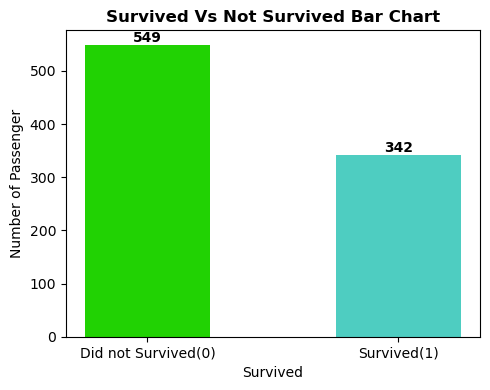

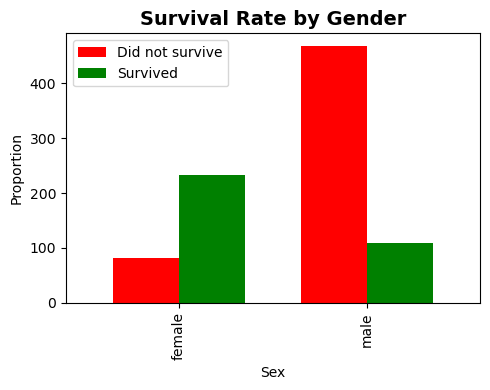

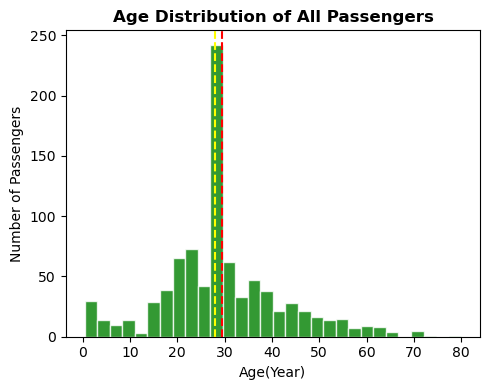

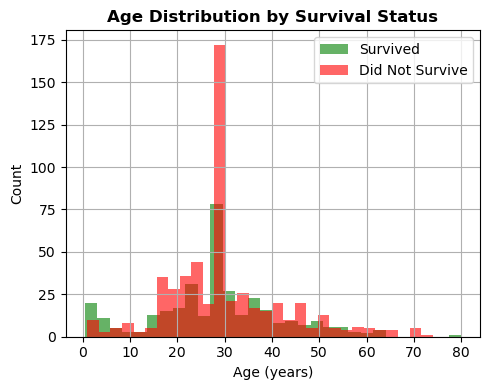

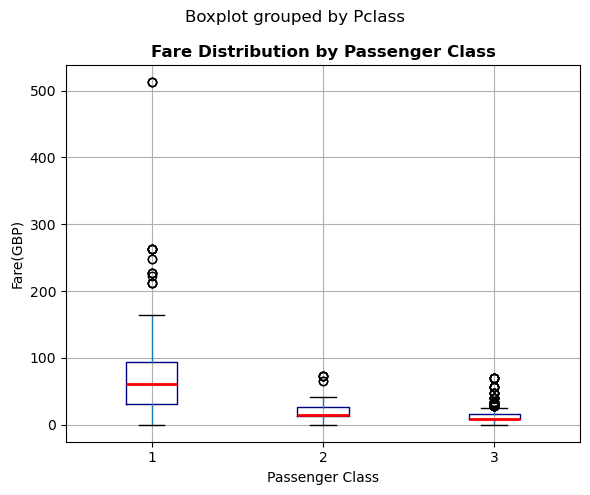

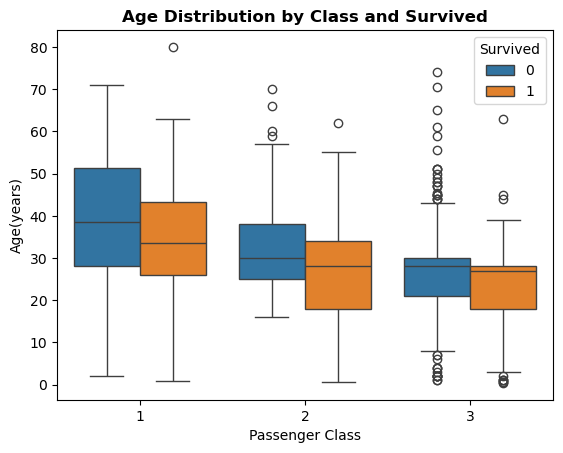

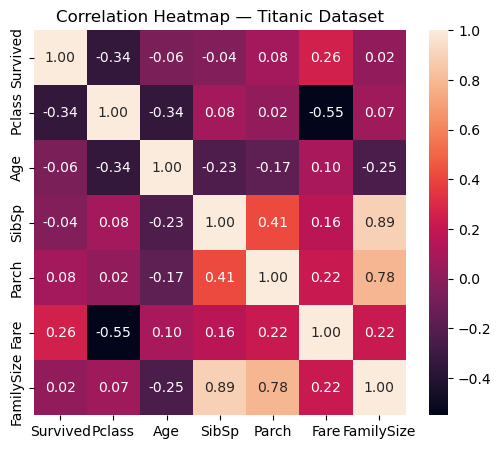

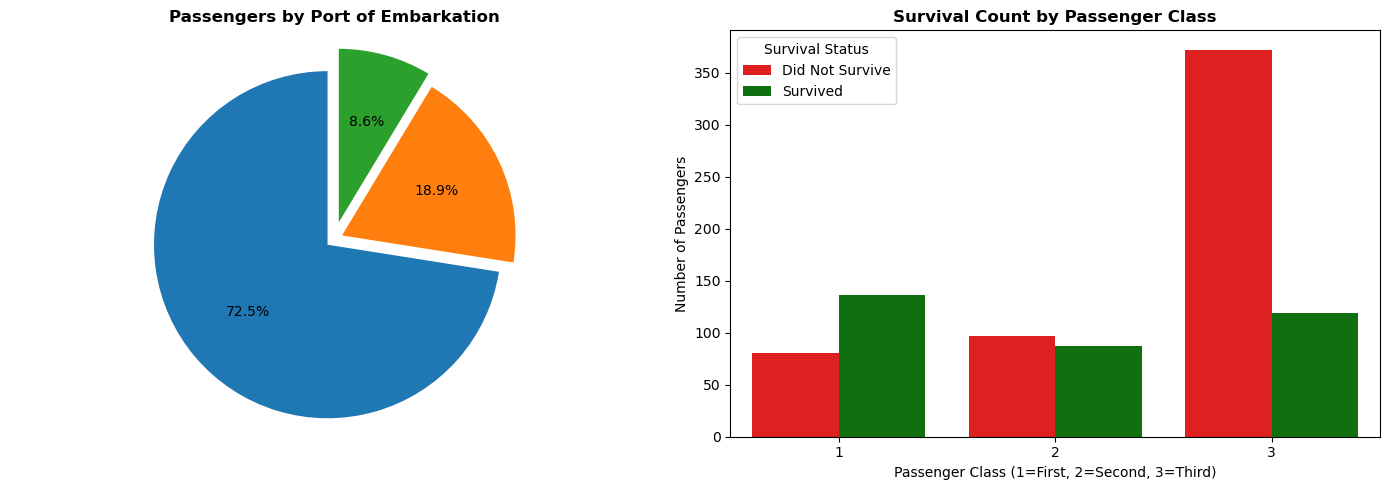

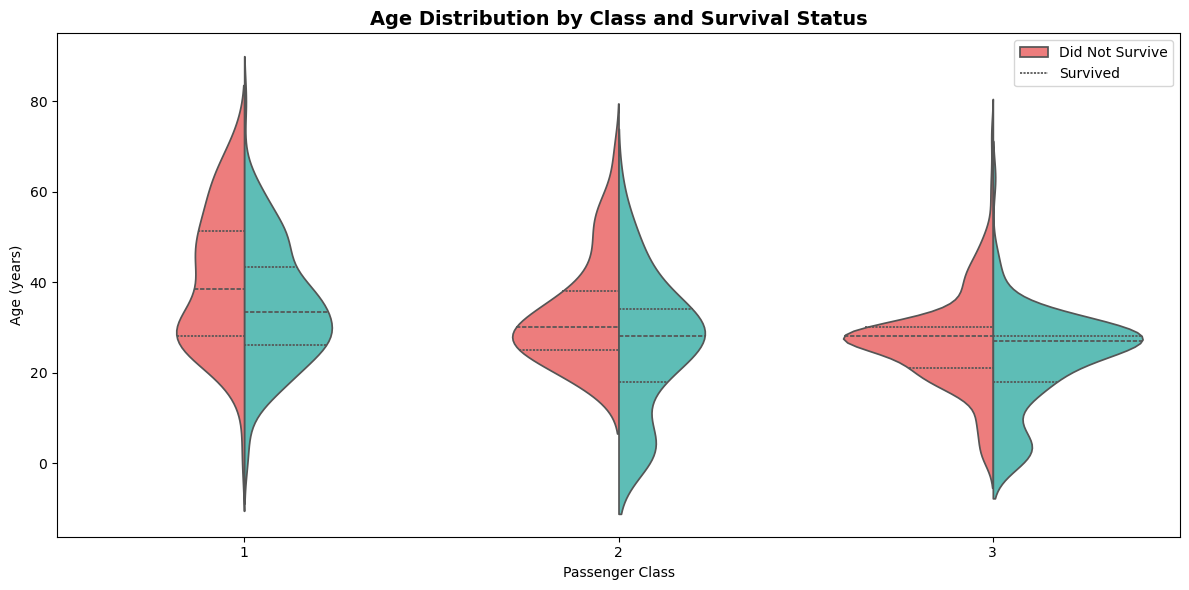

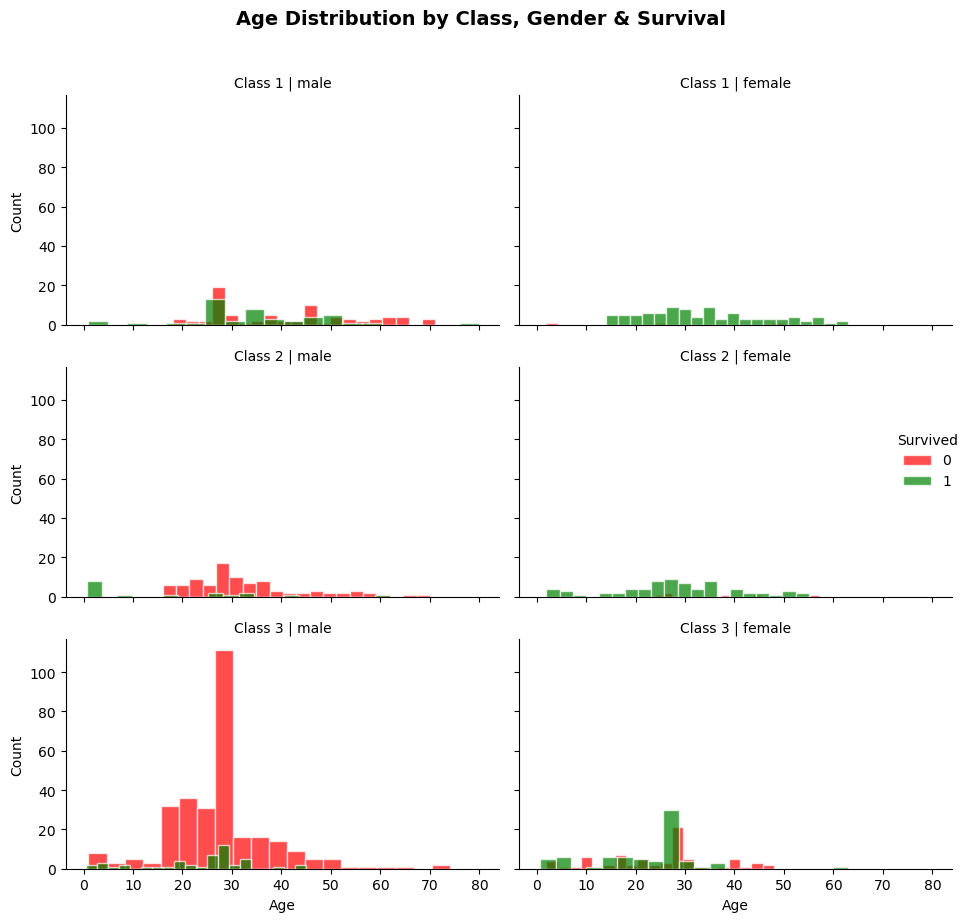

In [10]:
# ==============================================================================
# 5. DATA VISUALISATION
# ==============================================================================
# --- Plot 1: Survival Count Bar Chart ---
fig, ax = plt.subplots(figsize=(5, 4))
survived_counts = df['Survived'].value_counts()
ax.bar(['Did not Survived(0)', 'Survived(1)'], survived_counts, width=0.5, color=['#21D203', '#4ECDC1'])

for i, v in enumerate(survived_counts):
    ax.text(i, v + 5, str(v), ha='center', fontsize=10, fontweight='bold')

ax.set_title('Survived Vs Not Survived Bar Chart', fontweight='bold')
plt.xlabel('Survived')
plt.ylabel('Number of Passenger')
plt.tight_layout()
plt.show()

# --- Plot 2: Survival Rate by Gender ---
fig, ax = plt.subplots(figsize=(5, 4))
Survived_by_sex = df.groupby(['Sex', 'Survived']).size().unstack()
Survived_by_sex.plot(kind='bar', width=0.7, color=['red', 'green'], ax=ax)
ax.set_title('Survival Rate by Gender', fontsize=14, fontweight='bold')
ax.set_ylabel('Proportion')
plt.legend(['Did not survive', 'Survived'])
plt.tight_layout()
plt.show()

# --- Plot 3: Age Distribution Histogram ---
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(df['Age'], bins=30, edgecolor='white', color='green', alpha=0.8)
ax.axvline(df['Age'].mean(), color='red', linestyle='--')
ax.axvline(df['Age'].median(), color='yellow', linestyle='--')
plt.title('Age Distribution of All Passengers', fontweight='bold')
plt.xlabel('Age(Year)')
plt.ylabel('Number of Passengers')
plt.tight_layout()
plt.show()

# --- Plot 4: Age Distribution by Survival Count ---
fig, ax = plt.subplots(figsize=(5, 4))
df[df['Survived'] == 1]['Age'].hist(ax=ax, bins=30, alpha=0.6, color='green', label='Survived')
df[df['Survived'] == 0]['Age'].hist(ax=ax, bins=30, alpha=0.6, color='red', label='Did Not Survive')
ax.set_title('Age Distribution by Survival Status', fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 5: Fare Distribution Box Plot ---
fig, ax = plt.subplots(figsize=(6, 5))
df.boxplot(column='Fare', by='Pclass', ax=ax, boxprops=dict(color='navy'), medianprops=dict(color='red', linewidth=2))
plt.title('Fare Distribution by Passenger Class', fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Fare(GBP)')
plt.tight_layout()
plt.show()

# --- Plot 6: Age Distribution by Class and Survived ---
plt.figure()
sns.boxplot(x='Pclass', y='Age', hue='Survived', data=df)
plt.title('Age Distribution by Class and Survived', fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Age(years)')
plt.show()

# --- Plot 7: Heatmap - Correlation Matrix ---
plt.figure(figsize=(6, 5))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']].corr(), annot=True, fmt=".2f", cmap="rocket")
plt.title('Correlation Heatmap — Titanic Dataset')
plt.show()

# --- Plot 8: Pie Chart & Countplot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sidebar_embarked = df['Embarked'].value_counts()
axes[0].pie(sidebar_embarked.values, autopct='%1.1f%%', explode=(0.05, 0.05, 0.1), startangle=90)
axes[0].set_title('Passengers by Port of Embarkation', fontweight='bold')
axes[0].axis('equal')

sns.countplot(data=df, x='Pclass', hue='Survived', palette={0: 'red', 1: 'green'}, ax=axes[1])
axes[1].set_title('Survival Count by Passenger Class', fontweight='bold')
axes[1].set_xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
axes[1].set_ylabel('Number of Passengers')
axes[1].legend(['Did Not Survive', 'Survived'], title='Survival Status')
plt.tight_layout()
plt.show()

# --- Plot 9: Violin Plot ---
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Pclass', y='Age', hue='Survived', palette={0: '#FF6B6B', 1: '#4ECDC4'}, split=True, inner='quart')
plt.title('Age Distribution by Class and Survival Status', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Age (years)')
plt.legend(['Did Not Survive', 'Survived'], loc='upper right')
plt.tight_layout()
plt.savefig('plot6_violin.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 10: FacetGrid Histograms ---
g = sns.FacetGrid(df, row='Pclass', col='Sex', hue='Survived', palette={0: 'red', 1: 'green'}, height=3, aspect=1.5)
g.map(plt.hist, 'Age', bins=20, alpha=0.7, edgecolor='white')
g.add_legend(title='Survived')
g.set_axis_labels('Age', 'Count')
g.set_titles(row_template='Class {row_name}', col_template='{col_name}')
g.figure.suptitle('Age Distribution by Class, Gender & Survival', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
g.savefig('plot7_facetgrid.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ==============================================================================
# 6. FINAL SUMMARY REPORT
# ==============================================================================
print('=' * 60)
print(' TITANIC DATASET – KEY FINDINGS SUMMARY')
print('=' * 60)

total = len(df)
survived = df['Survived'].sum()

print(f'\nTotal Passengers Analysed : {total}')
print(f'Total Survivors          : {survived} ({ (survived/total*100):.1f}%)')
print(f'Total Deaths             : {total-survived} ({ ((total-survived)/total*100):.1f}%)')

print('\n--- SURVIVAL BY GENDER ---')
for sex, rate in df.groupby('Sex')['Survived'].mean().items():
    print(f'{sex.capitalize():<8}: {rate*100:.1f}% survival rate')

print('\n--- SURVIVAL BY CLASS ---')
for cls, rate in df.groupby('Pclass')['Survived'].mean().items():
    label = {1: 'First ', 2: 'Second', 3: 'Third '}[cls]
    bar = '#' * int(rate * 30)
    print(f'Class {label}: {bar} {rate*100:.1f}%')

print('\n--- AGE STATISTICS ---')
print(f'Average Age: {df["Age"].mean():.1f} years')
print(f'Youngest   : {df["Age"].min():.1f} years')
print(f'Oldest     : {df["Age"].max():.1f} years')
print('=' * 60)

 TITANIC DATASET – KEY FINDINGS SUMMARY

Total Passengers Analysed : 891
Total Survivors          : 342 (38.4%)
Total Deaths             : 549 (61.6%)

--- SURVIVAL BY GENDER ---
Female  : 74.2% survival rate
Male    : 18.9% survival rate

--- SURVIVAL BY CLASS ---
Class First : ################## 63.0%
Class Second: ############## 47.3%
Class Third : ####### 24.2%

--- AGE STATISTICS ---
Average Age: 29.4 years
Youngest   : 0.4 years
Oldest     : 80.0 years
